# Assignment 1

Note: This notebook file for the assignment has deviations from the course guide with respect to the structure, sentence framing, question framing and numbering. Please consider this notebook file structure as the final structure and follow this.

In this assignment, you will explore the CIFAR10 dataset. 

You have to download the dataset from Pytorch.

Comment your code and indicate what the different instructions are doing and what you are showing and printing. 
When printing figures do not forget about the title, x and y labels. The font size should be matching the text size of the text in your report. 
Do not forget to add legends to the plots. 

In [32]:
%pip install matplotlib numpy scikit-learn

  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 799.2 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.9 MB 1.0 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/8.9 MB 1.1 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/8.9 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.9 MB 1.1 MB/s eta 0:00:07
   ---------- ----------------------------- 2.4/8.9 MB 1.5 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/8.9 MB 1.6 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/8.9 MB 1

------------------------

In [1]:
# Load all the needed packages for this assignment here
import matplotlib.pyplot as plt
import numpy as np

#### Exercise 1.1 - Load data

**a)** Load the CIFAR10 dataset. 

**b)** Print the number of samples and the number of classes present in the dataset. 

**c)** Also print the shape of an image in the dataset. 

In [2]:
# Ex.1.1a,b & c
import torchvision

# A (Down)loading the dataset
dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=True
)

# B1 Printing the number of samples
samples_num = len(dataset)
print(f'{samples_num} samples in the CIFAR 10 dataset')

# B.2 Printing the number of classes present in the dataset
classes_num = len(dataset.classes)
print(f'{classes_num} classes in the CIFAR 10 dataset')

# C Printing the shape of the first image in the dataset
shape_0 = dataset.data[0].shape
print(f'Shape of first entry in the dataset: {shape_0}')


50000 samples in the CIFAR 10 dataset
10 classes in the CIFAR 10 dataset
Shape of first entry in the dataset: (32, 32, 3)


#### Exercise 1.2 - Quantify dataset

**a)** Print the number of samples per category.

In [3]:
# Ex.1.2a your code here
# Loading the classes
classes = dataset.classes

# B: Empty counts array for the bar chart
counts = []

# A: looping over the classes
for i, class_ in enumerate(classes):

    # A:Counting the entries per class
    count = dataset.targets.count(i)

    # A: printing results
    print(f'{class_}: {count}')

    # B: Storing the count for the class
    counts.append(count)


airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


**b)** Plot the number of samples per category using a bar plot.

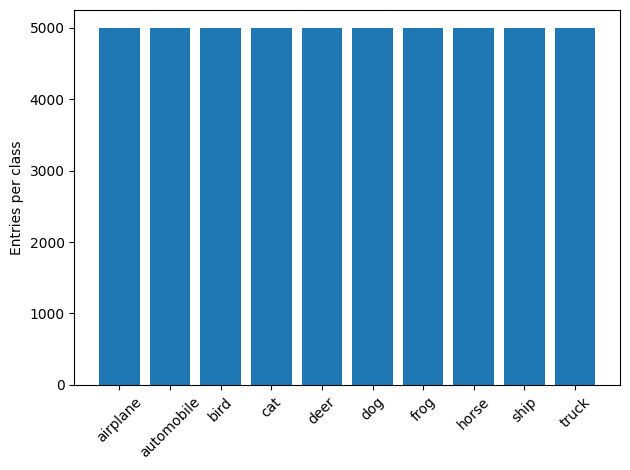

In [5]:
# Ex.1.2b your code here
# print(counts)

# Setup the figure
fig, ax = plt.subplots()

# Setup the bar axis
ax.bar(classes, counts, label=classes)

# Set the y axis label and title
ax.set_ylabel('Entry count')
ax.set_ylabel('Entries per class')

# Rotate the labels so the x-axis words dont overlap
plt.xticks(rotation=45)
plt.tight_layout()

**Reflection: Answer the below question**

Are you working with a balanced or an unbalanced dataset? Are there majoritarian classes? Do you think this will affect the later analysis and training of your models?

> Your Answer (Double click to edit): We are working with a balanced dataset, all classes contain 5000 samples

#### Exercise 1.3 - Visualize images in your dataset

Create a figure with n x 4 sub-plots. The value of 'n' depends on the number of categories present in the dataset.
As the title of each row in your figure, indicate the category it belongs to.

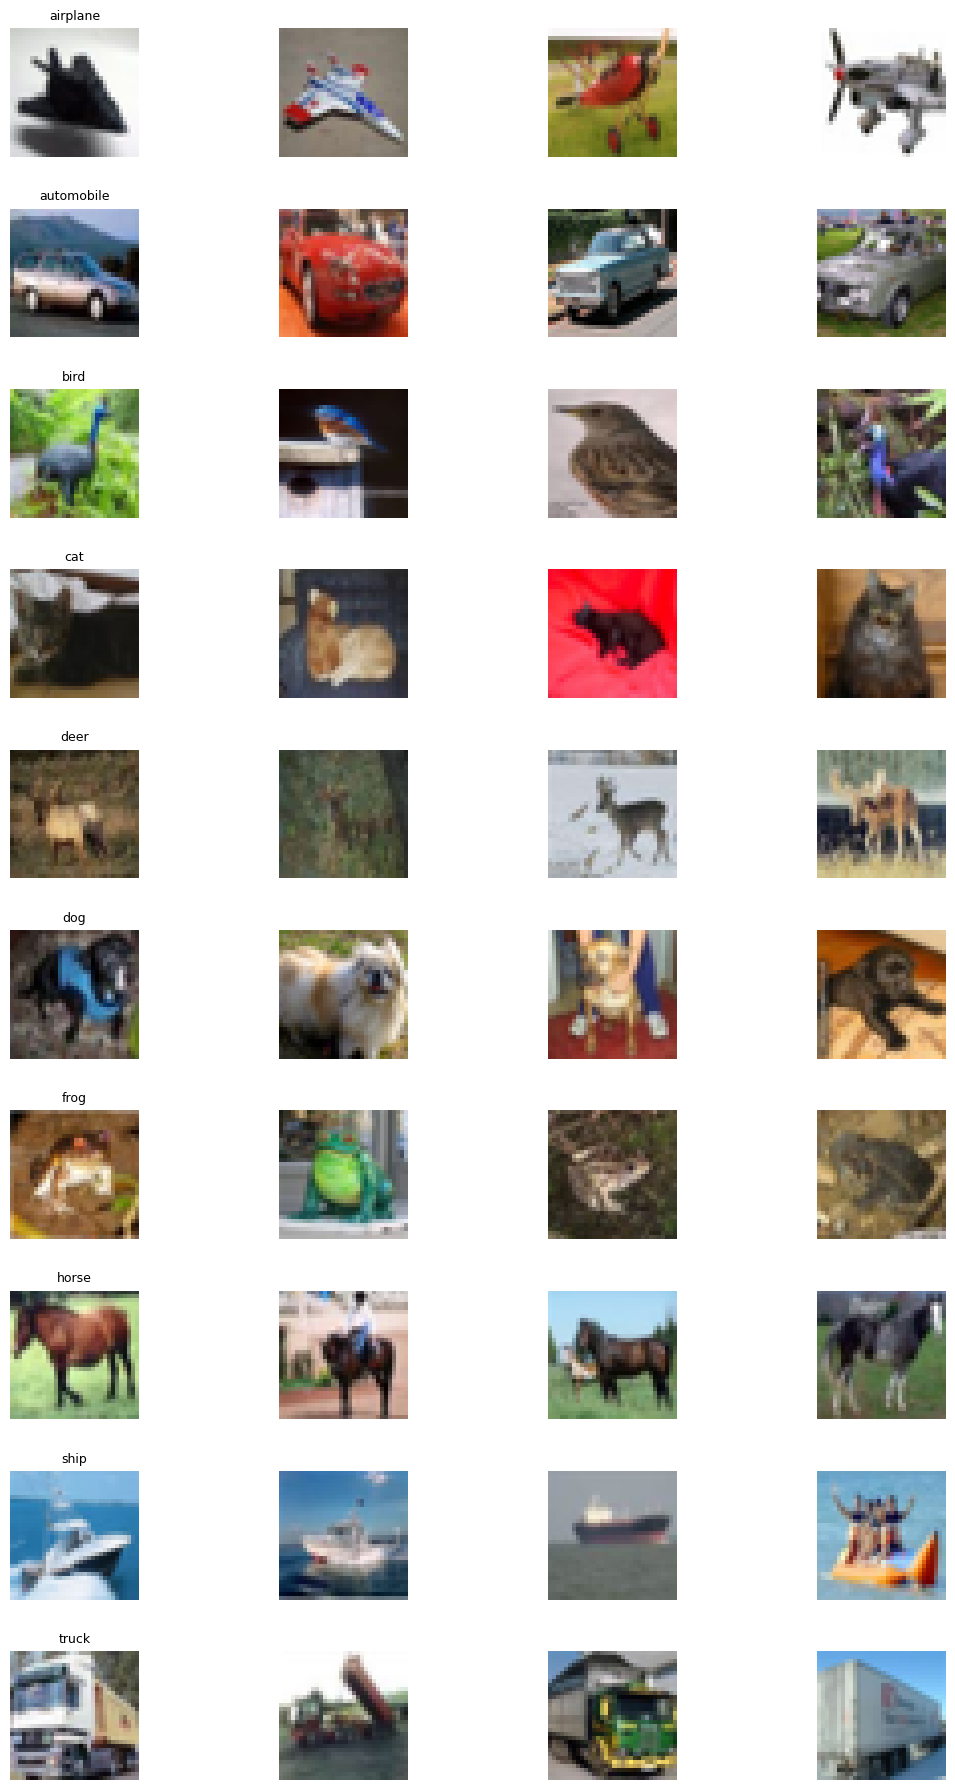

In [6]:
# Ex.1.3 your code here

# Create the plot
n = len(classes)
fig, axes = plt.subplots(n, 4, figsize=(12, max(3, n * 1.8)))

# Loop over the axes in the plot
for i, class_ in enumerate(classes):

    images = []
    # get the first 4 images i's for the current class
    for image_num, image_target in enumerate(dataset.targets):
        # check wether the image targets match the class
        if image_target == i:
            images.append(image_num)
        
        # break off the loop when we have 4 images
        if len(images) >= 4:
            break
    
    # Plot the images in each row
    for j in range(4):
        ax = axes[i,j]
        img = dataset.data[images[j]]
        ax.imshow(img)

        # for the first column add the class as title
        if j == 0:
            ax.set_title(dataset.classes[dataset.targets[images[j]]], fontsize=9)

        ax.axis('off')

    
plt.tight_layout()
fig.subplots_adjust(left=0.12, hspace=0.4, wspace=0.15)

plt.show()


#### Exercise 1.4 - RGB feature extraction

Extract RGB values from each image in your dataset as three seperate lists(one per channel). Each list should have 8 values. To do so, you can compute the histogram of each channel with 8 bins. Then you have to concatenate the values of all the three channels together resulting in a feature vector of size 24. This feature vector is the descriptor of an image in your dataset. You will have to do this for all the images present in your dataset in order to get the overall RGB descriptor which will be of size (n,24). Here 'n' depends on the number of samples present in the dataset. 

In [13]:
from tqdm import tqdm

# amount of bins for the histogram
bins = 8

# amount of samples
n_samples = len(dataset.data)

# create the empty vector that stores the RGB descriptors of all images
rgb_descriptors = np.zeros((n_samples, bins * 3))

# loop over the images
for i, img in tqdm(enumerate(dataset.data)):
    # Extract individual channels data
    r_channel = img[:, :, 0]
    g_channel = img[:, :, 1]
    b_channel = img[:, :, 2]

    # compute a histogram for each channel
    r_hist, bin_edges = np.histogram(r_channel, bins=bins, range=(0,256))
    g_hist, bin_edges = np.histogram(g_channel, bins=bins, range=(0, 256))
    b_hist, bin_edges = np.histogram(b_channel, bins=bins, range=(0, 256))
    
    # concatenate the histograms into a feature vector 
    feature_vector = np.concatenate([r_hist, g_hist, b_hist])

    
    rgb_descriptors[i] = feature_vector

print(f'RGB descriptors shape: {rgb_descriptors.shape}')

50000it [00:18, 2731.45it/s]

RGB descriptors shape: (50000, 24)


#### Exercise 1.5 - Compute the inter-class variability of your dataset.

Inter-class correlation aims at understanding the relationship/correlation among the classes/categories present in your dataset. For this, you could compute a measure (for example mean, std etc.) collectively for all the samples belonging to each and every class of the dataset. Then you could make use of this measure to find the correlation among the classes/categories using the standard pandas dataframe correlation function. Link: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

In [36]:
import pandas as pd
from sklearn.metrics import silhouette_score

# Ex.1.5 your code here
labels_enum = np.array(dataset.targets)

# Compute statistics per class
means = []
stdevs = []
for i in range(len(classes)):
    # select the descriptors
    class_descriptors = rgb_descriptors[labels_enum == i]
    # print(class_descriptors)
    
    # calc statistics
    mean = class_descriptors.mean(axis=0)
    stdev = class_descriptors.std(axis=0)

    # add them to the list
    means.append(mean)
    stdevs.append(stdev)

# Means => Array of 10 (one for each class)
#           |=>  each entry -> array of 24 (for each bin (8 bins*3 channels))
print(len(means))
print(len(means[0]))

# Create a 10 (classes) X 24 (means) dataframe with means for all bins for each class
df_means = pd.DataFrame(means, index=classes)

corr_classes = df_means.T.corr()
print(corr_classes.loc["airplane"])
corr_classes

10
24
airplane      1.000000
automobile    0.052321
bird          0.470928
cat           0.139518
deer          0.322096
dog           0.249280
frog          0.123002
horse         0.315648
ship          0.887582
truck         0.337923
Name: airplane, dtype: float64


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
airplane,1.000000,0.052321,0.470928,0.139518,0.322096,0.249280,0.123002,0.315648,0.887582,0.337923
automobile,0.052321,1.000000,0.806705,0.916883,0.881101,0.863930,0.931807,0.866904,0.355914,0.890496
bird,0.470928,0.806705,1.000000,0.916491,0.979866,0.948224,0.907693,0.968539,0.674754,0.835521
cat,0.139518,0.916883,0.916491,1.000000,0.954946,0.984555,0.981524,0.962153,0.417146,0.837122
deer,0.322096,0.881101,0.979866,0.954946,1.000000,0.962833,0.959474,0.984896,0.564242,0.876925
dog,0.249280,0.863930,0.948224,0.984555,0.962833,1.000000,0.952901,0.968334,0.525305,0.806994
frog,0.123002,0.931807,0.907693,0.981524,0.959474,0.952901,1.000000,0.956356,0.374512,0.859290
horse,0.315648,0.866904,0.968539,0.962153,0.984896,0.968334,0.956356,1.000000,0.530659,0.894939
ship,0.887582,0.355914,0.674754,0.417146,0.564242,0.525305,0.374512,0.530659,1.000000,0.504796
truck,0.337923,0.890496,0.835521,0.837122,0.876925,0.806994,0.859290,0.894939,0.504796,1.000000


**c)** Compute the Silhouette score. 

The Silhouette score is used to assess the performance of using unsupervised machine learning (clustering). We can also use it here to assess the compactness of the extracted descriptors per category and for the group of categories as their mean.

You can use the function available in Sklearn - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

In [ ]:
# Ex.1.5c your code here
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silscore = silhouette_score(rgb_descriptors, labels_enum)
print(f"Silhouette score: {silscore}")

-0.08492854865203082


**Reflection: (Answer the below questions)** 

**1.** Does Intra-class correlation score/coefficient help you assess the degree of similarity among the samples of a category?
> Your Answer (Double click to edit): Yes it does, if the intra-class correlation score is large (close to 1), the samples are tightly clustered and when it is small the descriptor does not distinguish the members of the class well. The comparisson of the inter class correlation score alows us to see which categories are more internally consistent and which are more varied

**2.** What can you deduce from the Inter-class correlation and Silhouette score?
> Your Answer (Double click to edit): 

> The inter class correlation matrix tells us which clases have similar colour distributions (for example a truck and car may have a high color correlation, but a horse and truck not). If the inter class correlation of two classes is large then the means are generally more similar. 

> The silhouette score looks at the indivudal samples in the descriptors array and the true labels. It tells us if our descriptors sepperate indivudal examples according to the true labels. If its near +1 it means that the samples are closer to the other sampls of their class, a value of 0 indicates the clouds of samples overlaps, and a negative value such as -0.0849... suggests that the point is more similar to another cluster than their ground truth one.

#### Exercise 1.6 - Dimensionality reduction for visualization 

We can visualize large datasets having higher dimensions or features in 2- or 3-dimensional spaces. For this, you need to reduce the dimensionality of the data. 

In this exercise, you are asked to use PCA for reducing dimensionality.

Link to function to apply PCA: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

Create the following two figures:

**a)** Rely on the first 2 principal components to plot the samples of your dataset. Use one color per class.

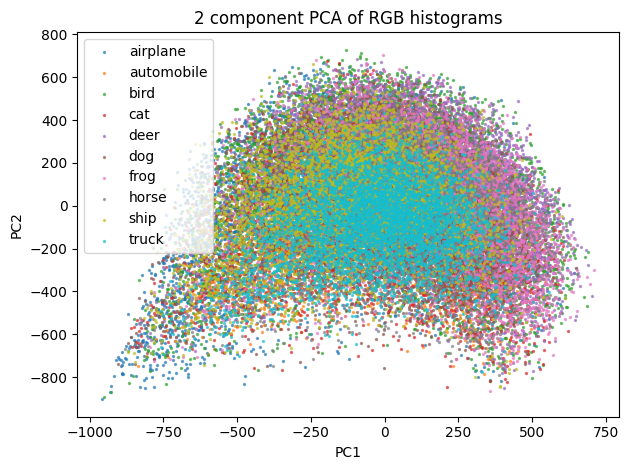

In [53]:
# Ex.1.6a your code here
from sklearn.decomposition import PCA

# fit the 2D pca
pca = PCA(n_components=3)
pca_results = pca.fit_transform(rgb_descriptors)

# plot the 2D pca results
# create the plot 
fig, ax = plt.subplots()

# setup the colors per class (10 classes)
colors = plt.cm.tab10(np.linspace(0,1,10))

# loop over the classes
for i, name in enumerate(classes):
    # create a mask to idenfify which samples belong to the current class
    mask = labels_enum == i

    # plot the data
    ax.scatter(pca_results[mask,0], pca_results[mask,1],
               s=2, color=colors[i], label=name, alpha=0.6)

# finish the graph
ax.set_title("2 component PCA of RGB histograms")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(loc='best')
plt.tight_layout()
plt.show()


**b)** Rely on the first 3 principal components to create a 3D plot. Use one color per class.

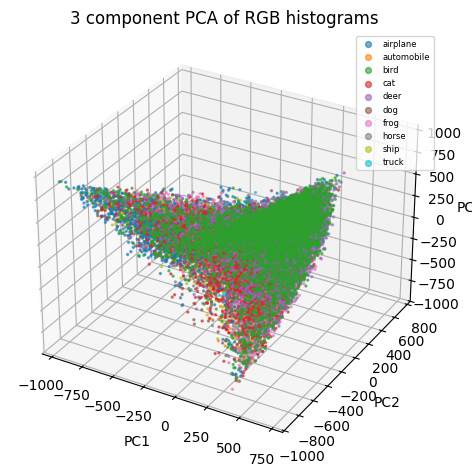

In [56]:
# Ex.1.6b your code here
# creat ethe figure
fig = plt.figure()

# create the 3d plot
ax3 = fig.add_subplot(111, projection='3d')

# loop over classes
for i, name in enumerate(classes):

    # mask out the unnesecary data
    mask = labels_enum == i

    # plot the data
    ax3.scatter(pca_results[mask,0], pca_results[mask,1], pca_results[mask,2],
                s=2, color=colors[i], label=name, alpha=0.6)

# set title and legend etc
ax3.set_title("3 component PCA of RGB histograms")
ax3.set_xlabel("PC1"); ax3.set_ylabel("PC2"); ax3.set_zlabel("PC3")
ax3.legend(markerscale=3, fontsize=6, loc='upper right')
plt.tight_layout()
plt.show()

#### Exercise 1.7 - Reflection

Reflect on the following questions.

**a)** Will you obtain the same visualisation in the feature space for different extracted features?
> Your Answer (Double click to edit): 
> No, when using different extracted features they will result in a different visualization. Using a different feature type will result in other descriptors which typically also form a different point cloud
    
**b)** Are the classes distinguishable on the feature space when relying on PCA over RGB?
> Your Answer (Double click to edit): 
> No when looking at the PCA graphs over RGB the classes are not very distinguiable and are mingled together.
    
**c)** What other visualization could you include to better describe your data?
> Your Answer (Double click to edit): Perhaps a heatmap showing the interclass correlation for the different classes better describe the data.

#### [Optional] Exercise: Repeat experiments with different image descriptors

e.g. 
- Harris Corner Detection

- Shi-Tomasi Corner Detector and Good Features to Track

- Scale-Invariant Feature Transform (SIFT)

- Speeded-up robust features (SURF)

- Features from Accelerated Segment Test (FAST)

- Blob Detectors With LoG, DoG, and DoH

If you have OpenCV installed you can follow this example,
https://automaticaddison.com/image-feature-detection-description-and-matching-in-opencv/

When using Scikit-image,
https://scikit-image.org/docs/dev/api/skimage.feature.html?highlight=hog